In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf
import networkx as nx
from pgmpy.base.DAG import DAG

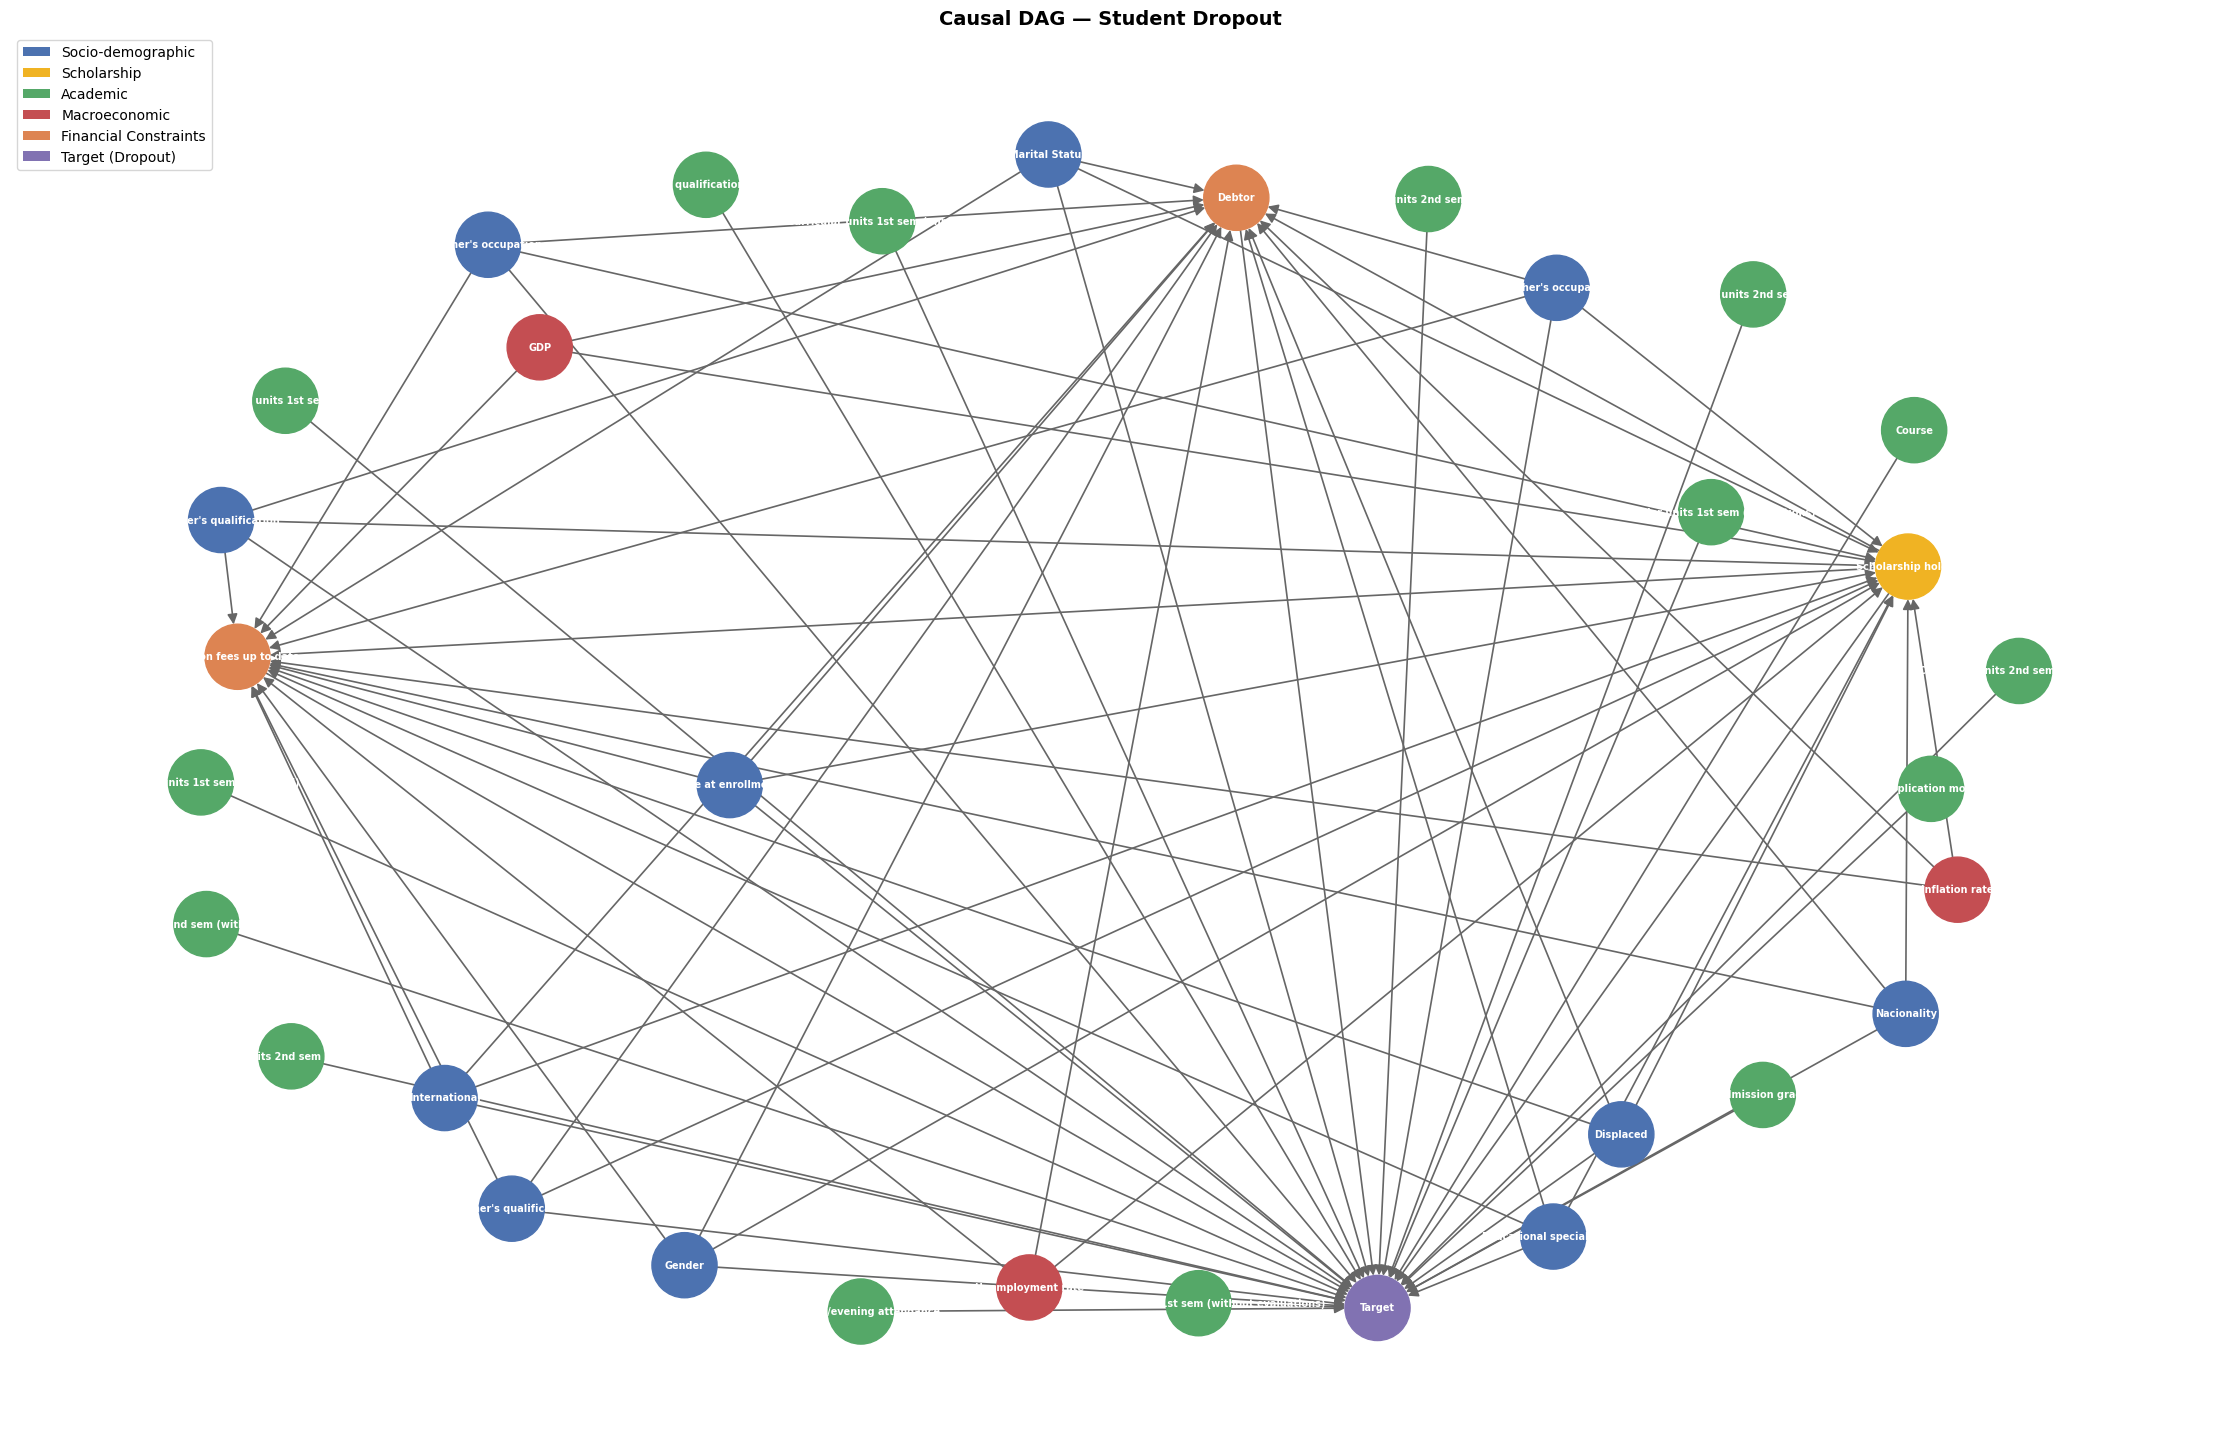

In [ ]:
digraph = nx.DiGraph(
    [
        # Socio-demographic => Scholarship
        ('Marital Status',            'Scholarship holder'),
        ("Mother's qualification",    'Scholarship holder'),
        ("Father's qualification",    'Scholarship holder'),
        ("Mother's occupation",       'Scholarship holder'),
        ("Father's occupation",       'Scholarship holder'),
        ('Nacionality',               'Scholarship holder'),
        ('Gender',                    'Scholarship holder'),
        ('Age at enrollment',         'Scholarship holder'),
        ('Displaced',                 'Scholarship holder'),
        ('Educational special needs', 'Scholarship holder'),
        ('International',             'Scholarship holder'),

        # Socio-demographic => Financial Constraints

        ('Marital Status',            'Debtor'),
        ("Mother's qualification",    'Debtor'),
        ("Father's qualification",    'Debtor'),
        ("Mother's occupation",       'Debtor'),
        ("Father's occupation",       'Debtor'),
        ('Nacionality',               'Debtor'),
        ('Gender',                    'Debtor'),
        ('Age at enrollment',         'Debtor'),
        ('Displaced',                 'Debtor'),
        ('Educational special needs', 'Debtor'),
        ('International',             'Debtor'),


        ('Marital Status',            'Tuition fees up to date'),
        ("Mother's qualification",    'Tuition fees up to date'),
        ("Father's qualification",    'Tuition fees up to date'),
        ("Mother's occupation",       'Tuition fees up to date'),
        ("Father's occupation",       'Tuition fees up to date'),
        ('Nacionality',               'Tuition fees up to date'),
        ('Gender',                    'Tuition fees up to date'),
        ('Age at enrollment',         'Tuition fees up to date'),
        ('Displaced',                 'Tuition fees up to date'),
        ('Educational special needs', 'Tuition fees up to date'),
        ('International',             'Tuition fees up to date'),


        # Scholarship => Financial Constraints
        ('Scholarship holder', 'Debtor'),
        ('Scholarship holder', 'Tuition fees up to date'),

        # Socio-demographic => Dropout
        ('Marital Status',            'Target'),
        ("Mother's qualification",    'Target'),
        ("Father's qualification",    'Target'),
        ("Mother's occupation",       'Target'),
        ("Father's occupation",       'Target'),
        ('Nacionality',               'Target'),
        ('Gender',                    'Target'),
        ('Age at enrollment',         'Target'),
        ('Displaced',                 'Target'),
        ('Educational special needs', 'Target'),
        ('International',             'Target'),

        # Scholarship => Dropout
        ('Scholarship holder', 'Target'),

        # Academic Factors => Dropout
        ('Admission grade',                                'Target'),
        ('Previous qualification',                         'Target'),
        ('Previous qualification (grade)',                 'Target'),
        ('Course',                                         'Target'),
        ('Daytime/evening attendance',                     'Target'),
        ('Application mode',                               'Target'),
        ('Curricular units 1st sem (approved)',            'Target'),
        ('Curricular units 1st sem (grade)',               'Target'),
        ('Curricular units 1st sem (enrolled)',            'Target'),
        ('Curricular units 1st sem (evaluations)',         'Target'),
        ('Curricular units 1st sem (without evaluations)', 'Target'),
        ('Curricular units 2nd sem (approved)',            'Target'),
        ('Curricular units 2nd sem (grade)',               'Target'),
        ('Curricular units 2nd sem (enrolled)',            'Target'),
        ('Curricular units 2nd sem (evaluations)',         'Target'),
        ('Curricular units 2nd sem (without evaluations)', 'Target'),

        # Macroeconomic => Financial Constraints
        ('Unemployment rate', 'Debtor'),
        ('Inflation rate',    'Debtor'),
        ('GDP',               'Debtor'),
        ('Unemployment rate', 'Tuition fees up to date'),
        ('Inflation rate',    'Tuition fees up to date'),
        ('GDP',               'Tuition fees up to date'),

        # Macroeconomic => Dropout
        ('Unemployment rate', 'Scholarship holder'),
        ('Inflation rate',    'Scholarship holder'),
        ('GDP',               'Scholarship holder'),

        # Financial Constraints => Dropout
        ('Debtor',                  'Target'),
        ('Tuition fees up to date', 'Target'),
    ]
)

G = DAG(digraph)

color_map = {
    # Socio-demographic: 
    'Marital Status': '#4C72B0', "Mother's qualification": '#4C72B0',
    "Father's qualification": '#4C72B0', "Mother's occupation": '#4C72B0',
    "Father's occupation": '#4C72B0', 'Nacionality': '#4C72B0',
    'Gender': '#4C72B0', 'Age at enrollment': '#4C72B0',
    'Displaced': '#4C72B0', 'Educational special needs': '#4C72B0',
    'International': '#4C72B0',
    # Scholarship:
    'Scholarship holder': '#F0B323',
    # Academic:
    'Admission grade': '#55A868', 'Previous qualification (grade)': '#55A868',
    'Course': '#55A868', 'Daytime/evening attendance': '#55A868',
    'Application mode': '#55A868',
    'Curricular units 1st sem (approved)': '#55A868',
    'Curricular units 1st sem (grade)': '#55A868',
    'Curricular units 1st sem (enrolled)': '#55A868',
    'Curricular units 1st sem (evaluations)': '#55A868',
    'Curricular units 1st sem (without evaluations)': '#55A868',
    'Curricular units 2nd sem (approved)': '#55A868',
    'Curricular units 2nd sem (grade)': '#55A868',
    'Curricular units 2nd sem (enrolled)': '#55A868',
    'Curricular units 2nd sem (evaluations)': '#55A868',
    'Curricular units 2nd sem (without evaluations)': '#55A868',
    # Macroeconomic:
    'Unemployment rate': '#C44E52', 'Inflation rate': '#C44E52', 'GDP': '#C44E52',
    # Financial constraints:
    'Debtor': '#DD8452', 'Tuition fees up to date': '#DD8452',
    # Target:
    'Target': '#8172B2',
}

node_colors = [color_map.get(n, '#999999') for n in G.nodes()]

plt.figure(figsize=(22, 14))
pos = nx.spring_layout(digraph, seed=42, k=2.5)
nx.draw(
    digraph, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2200,
    font_size=7,
    font_color='white',
    font_weight='bold',
    edge_color='#666666',
    arrows=True,
    arrowsize=15,
    width=1.2,
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Socio-demographic'),
    Patch(facecolor='#F0B323', label='Scholarship'),
    Patch(facecolor='#55A868', label='Academic'),
    Patch(facecolor='#C44E52', label='Macroeconomic'),
    Patch(facecolor='#DD8452', label='Financial Constraints'),
    Patch(facecolor='#8172B2', label='Target (Dropout)'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.title("Causal DAG — Student Dropout", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()